# 🔍 04 – Clustering: Analisis Pola Batch Granulasi dengan K-Means

**Proyek :** AI-Based Pharmaceutical Data Selection & Monitoring System  
**Tim     :** PJK-GM016 | Pijak × IBM SkillsBuild  
**Pipeline:**  
`01_preprocessing.ipynb` → `02_eda.ipynb` → `03_modeling.ipynb` → **`04_clustering.ipynb`** → `05_dashboard.ipynb`

---
### Tujuan Notebook
1. **K-Means Clustering** – Kelompokkan batch berdasarkan kesamaan parameter proses (suhu, waktu, KA, yield)  
2. **Elbow Method + Silhouette Score** – Tentukan jumlah cluster optimal (k)  
3. **PCA Visualization** – Proyeksi cluster ke 2D/3D untuk inspeksi visual  
4. **Profil Cluster** – Karakterisasi setiap cluster: parameter dominan & tingkat defect  
5. **Analisis Korelasi** – Heatmap korelasi antar fitur utama  
6. **Feature Importance** – Fitur paling berpengaruh terhadap keanggotaan cluster  
7. **Export** – Simpan cluster label ke dataset & model ke pkl  

> **Input :** `dataset_clean.csv` atau `dataset_with_predictions.csv`
> **Output:** `dataset_clustered.csv`, `models/kmeans_model.pkl`, `models/pca_model.pkl`


## ⚙️ 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json
warnings.filterwarnings('ignore')

os.makedirs('models',  exist_ok=True)
os.makedirs('outputs', exist_ok=True)

from sklearn.cluster         import KMeans
from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.metrics         import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.inspection      import permutation_importance
from sklearn.ensemble        import RandomForestClassifier
import joblib

sns.set_theme(style='whitegrid', font_scale=1.05)

# Warna & label konsisten dengan file lain
LABEL_MAP = {0: 'Normal', 1: 'Defect'}
PALETTE   = {0: '#2ecc71', 1: '#e74c3c'}
CLUSTER_COLORS = ['#3498db','#e67e22','#9b59b6','#1abc9c','#e74c3c',
                   '#f39c12','#2c3e50','#27ae60']
TARGET = 'is_defect'

print('✅ Library berhasil diimport')
print(f'   scikit-learn : {__import__("sklearn").__version__}')
print(f'   pandas       : {pd.__version__}')


✅ Library berhasil diimport
   scikit-learn : 1.8.0
   pandas       : 3.0.3


## 📂 2. Load Data

In [ ]:
import os
if os.path.exists('outputs/dataset_with_predictions.csv'):
    df = pd.read_csv('outputs/dataset_with_predictions.csv', low_memory=False)
    print('✅ Loaded: outputs/dataset_with_predictions.csv')
elif os.path.exists('dataset_with_predictions.csv'):
    df = pd.read_csv('dataset_with_predictions.csv', low_memory=False)
    print('✅ Loaded: dataset_with_predictions.csv')
else:
    df = pd.read_csv('dataset_clean.csv', low_memory=False)
    print('⚠️  Loaded: dataset_clean.csv (jalankan 03_modeling.ipynb dulu untuk RF_Proba)')

print(f'Shape       : {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'Normal      : {int((df[TARGET]==0).sum())} batch')
print(f'Defect      : {int((df[TARGET]==1).sum())} batch')
print(f'Defect rate : {df[TARGET].mean()*100:.1f}%')


✅ Loaded: outputs/dataset_with_predictions.csv
Shape       : 46 baris × 150 kolom
Normal      : 35 batch
Defect      : 11 batch
Defect rate : 23.9%


## 🎯 3. Pemilihan Fitur untuk Clustering

Fitur clustering dipilih berdasarkan:
- **Relevansi proses** → mencakup parameter dari CB1 dan CB2
- **Korelasi EDA** → fitur dengan |r| > 0.20 terhadap `is_defect`
- **Ketersediaan data** → kolom yang valid > 70% baris

Fitur dikelompokkan menjadi 5 dimensi proses: **Suhu CB1**, **Suhu CB2**, **Waktu Granulasi**, **Kadar Air (KA)**, dan **Yield**.


In [ ]:
# Kandidat fitur clustering
CLUSTER_FEATURES = [
    # Waktu Granulasi CB1
    'cb1_waktu_lot1_ph1', 'cb1_waktu_lot1_ph2',
    'cb1_waktu_lot2_ph1', 'cb1_waktu_lot2_ph2',

    # Suhu Decoct CB1 
    'cb1_suhu_lot1_1', 'cb1_suhu_lot1_2',
    'cb1_suhu_lot2_1', 'cb1_suhu_lot2_2',
    'cb1_suhu_rata', 
    'cb1_suhu_std',   

    # Suhu DIOSNA CB1
    'cb1_suhu_diosna_lot1_1', 'cb1_suhu_diosna_lot1_2',
    'cb1_suhu_diosna_lot2_1', 'cb1_suhu_diosna_lot2_2',

    # Suhu Decoct CB2
    'cb2_suhu_lot1_1', 'cb2_suhu_lot1_2',
    'cb2_suhu_lot2_1', 'cb2_suhu_lot2_2',
    'cb2_suhu_lot3_1', 'cb2_suhu_lot3_2',
    'cb2_suhu_lot4_1', 'cb2_suhu_lot4_2',
    'cb2_suhu_rata',  
    'cb2_suhu_std',  

    # Suhu DIOSNA CB2
    'cb2_suhu_diosna_lot1_1', 'cb2_suhu_diosna_lot1_2',
    'cb2_suhu_diosna_lot2_1', 'cb2_suhu_diosna_lot2_2',
    'cb2_suhu_diosna_lot3_1', 'cb2_suhu_diosna_lot3_2',
    'cb2_suhu_diosna_lot4_1', 'cb2_suhu_diosna_lot4_2',

    # Waktu Granulasi CB2
    'cb2_waktu_lot1_ph1', 'cb2_waktu_lot2_ph1',
    'cb2_waktu_lot3_ph1', 'cb2_waktu_lot4_ph1',

    # Kadar Air CB1 & CB2
    'cb1_ka1', 'cb1_ka2', 'cb1_rata_ka',
    'cb2_ka1', 'cb2_ka2', 'cb2_ka3', 'cb2_ka4', 'cb2_rata_ka',
    'ck1_ka_setelah_ck',

    # Yield
    'cb1_pct_yield', 'cb1_yield_deviate',
    'ck1_pct_yield', 'ck1_yield_deviate',
    'cb2_pct_yield',

    # Jumlah granul
    'cb1_jml_granul_kg', 'cb2_jml_granul_kg',
    'cb1_jml_decoct_kg', 'cb2_jml_decoct_kg',

    # Mixer & Chopper CB1
    'cb1_mixer1', 'cb1_mixer2', 'cb1_chopper1', 'cb1_chopper2',

    # Mixer & Chopper CB2
    'cb2_mixer1', 'cb2_mixer2', 'cb2_mixer3', 'cb2_mixer4',
    'cb2_chopper1', 'cb2_chopper2', 'cb2_chopper3', 'cb2_chopper4',
]

# Filter kolom yang benar-benar ada di df
CLUSTER_FEATURES = [c for c in CLUSTER_FEATURES if c in df.columns]

print(f'Total fitur tersedia : {len(CLUSTER_FEATURES)}')
print()

# Cek missing value
df_clust = df[CLUSTER_FEATURES + [TARGET]].copy()
for col in CLUSTER_FEATURES:
    if df_clust[col].isna().any():
        df_clust[col].fillna(df_clust[col].median(), inplace=True)

X_raw = df_clust[CLUSTER_FEATURES].copy()
y     = df_clust[TARGET].astype(int)

# Scaling wajib untuk K-Means
scaler_clust = StandardScaler()
X_scaled     = scaler_clust.fit_transform(X_raw)

print(f'Fitur setelah filter : {len(CLUSTER_FEATURES)}')
print(f'Shape matrix         : {X_scaled.shape}')
print(f'Missing values       : {pd.DataFrame(X_scaled).isna().sum().sum()} (setelah imputasi)')


Total fitur tersedia : 66

Fitur setelah filter : 66
Shape matrix         : (46, 66)
Missing values       : 0 (setelah imputasi)


## 📐 4. Menentukan Jumlah Cluster Optimal

Dua metode digunakan bersama untuk memilih k optimal:
- **Elbow Method** – pilih k di mana penurunan inertia mulai melandai
- **Silhouette Score** – skor mendekati 1 = cluster lebih padat dan terpisah
- **Davies-Bouldin Index** – skor mendekati 0 = cluster lebih baik


In [ ]:
K_RANGE = range(2, 9)
inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# Tampilkan tabel
eval_df = pd.DataFrame({
    'k'              : list(K_RANGE),
    'Inertia'        : inertias,
    'Silhouette'     : silhouettes,
    'Davies-Bouldin' : db_scores,
})
print('=== Evaluasi Jumlah Cluster ===')
print(eval_df.round(4).to_string(index=False))
best_k_sil = eval_df.loc[eval_df['Silhouette'].idxmax(), 'k']
best_k_db  = eval_df.loc[eval_df['Davies-Bouldin'].idxmin(), 'k']
print(f'\n→ Silhouette terbaik : k = {best_k_sil}  ({eval_df.Silhouette.max():.4f})')
print(f'→ Davies-Bouldin min : k = {best_k_db}  ({eval_df["Davies-Bouldin"].min():.4f})')


=== Evaluasi Jumlah Cluster ===
 k   Inertia  Silhouette  Davies-Bouldin
 2 2532.0019      0.2569          1.5086
 3 2205.6863      0.1832          1.8011
 4 2052.5104      0.1896          1.4257
 5 1947.7269      0.0918          2.0122
 6 1824.1018      0.1820          1.1240
 7 1710.5776      0.1959          1.0524
 8 1638.4009      0.1180          1.4671

→ Silhouette terbaik : k = 2  (0.2569)
→ Davies-Bouldin min : k = 7  (1.0524)


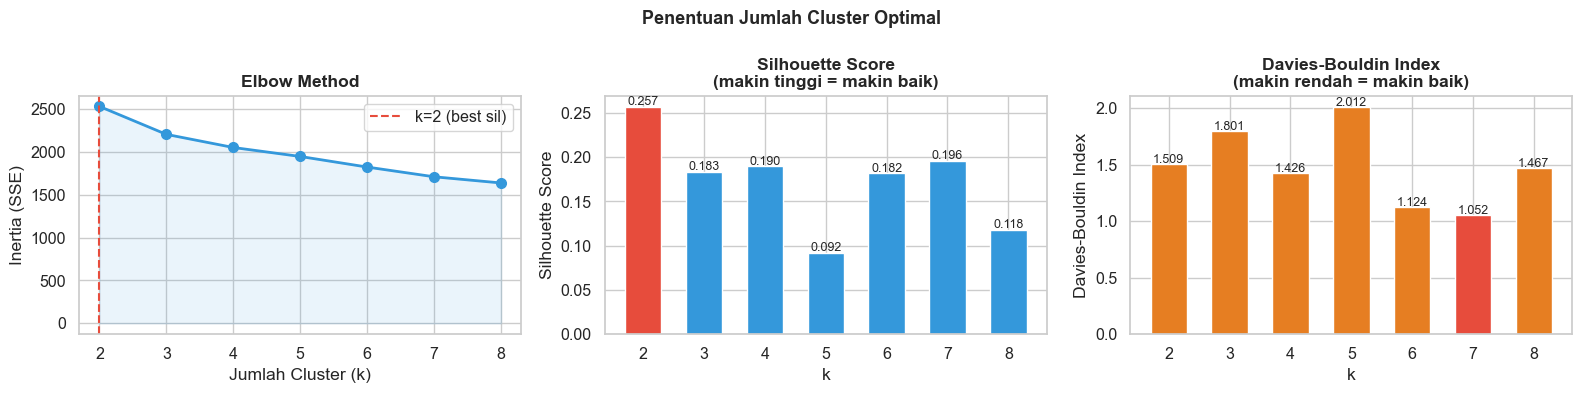

✅ Grafik tersimpan: outputs/clustering_k_selection.png


In [ ]:
# Visualisasi Elbow & Silhouette
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Penentuan Jumlah Cluster Optimal', fontsize=13, fontweight='bold')

k_list = list(K_RANGE)

# Elbow
axes[0].plot(k_list, inertias, 'o-', color='#3498db', lw=2, ms=7)
axes[0].fill_between(k_list, inertias, alpha=0.1, color='#3498db')
axes[0].axvline(best_k_sil, color='#e74c3c', linestyle='--', lw=1.5,
                label=f'k={best_k_sil} (best sil)')
axes[0].set_xlabel('Jumlah Cluster (k)'); axes[0].set_ylabel('Inertia (SSE)')
axes[0].set_title('Elbow Method', fontweight='bold'); axes[0].legend()
axes[0].set_xticks(k_list)

# Silhouette
colors_sil = ['#e74c3c' if k == best_k_sil else '#3498db' for k in k_list]
bars = axes[1].bar(k_list, silhouettes, color=colors_sil, edgecolor='white', width=0.6)
for bar, val in zip(bars, silhouettes):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\n(makin tinggi = makin baik)', fontweight='bold')
axes[1].set_xticks(k_list)

# Davies-Bouldin
colors_db = ['#e74c3c' if k == best_k_db else '#e67e22' for k in k_list]
bars2 = axes[2].bar(k_list, db_scores, color=colors_db, edgecolor='white', width=0.6)
for bar, val in zip(bars2, db_scores):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index\n(makin rendah = makin baik)', fontweight='bold')
axes[2].set_xticks(k_list)

plt.tight_layout()
plt.savefig('outputs/clustering_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik tersimpan: outputs/clustering_k_selection.png')


## 🎯 5. K-Means Clustering — Model Final

Berdasarkan hasil Elbow + Silhouette, pilih k terbaik dan latih model final.


In [ ]:
# Pilih k optimal
# Jika sil dan db sepakat → gunakan nilai itu
# Jika berbeda → prioritaskan silhouette
OPTIMAL_K = int(best_k_sil)
print(f'k optimal dipilih : {OPTIMAL_K}')
print(f'  (Silhouette terbaik pada k={best_k_sil}, Davies-Bouldin terbaik pada k={best_k_db})')

# Train K-Means final
kmeans = KMeans(
    n_clusters = OPTIMAL_K,
    random_state = 42,
    n_init   = 50,
    max_iter = 1000,
    algorithm = 'lloyd'
)
cluster_labels = kmeans.fit_predict(X_scaled)

# Tambahkan ke dataframe
df['Cluster']       = cluster_labels
df['Cluster_Label'] = df['Cluster'].apply(lambda x: f'Cluster {x}')

sil_final = silhouette_score(X_scaled, cluster_labels)
db_final  = davies_bouldin_score(X_scaled, cluster_labels)

print(f'\n✅ K-Means selesai')
print(f'   Silhouette Score  : {sil_final:.4f}')
print(f'   Davies-Bouldin    : {db_final:.4f}')
print(f'   Inertia           : {kmeans.inertia_:.2f}')
print()
print('Distribusi cluster:')
cluster_dist = df.groupby('Cluster').agg(
    Total     = (TARGET, 'count'),
    Normal    = (TARGET, lambda x: (x==0).sum()),
    Defect    = (TARGET, lambda x: (x==1).sum()),
    DefectRate= (TARGET, 'mean')
).round(3)
cluster_dist['DefectRate'] = (cluster_dist['DefectRate']*100).round(1).astype(str) + '%'
print(cluster_dist.to_string())


k optimal dipilih : 2
  (Silhouette terbaik pada k=2, Davies-Bouldin terbaik pada k=7)

✅ K-Means selesai
   Silhouette Score  : 0.2569
   Davies-Bouldin    : 1.5086
   Inertia           : 2532.00

Distribusi cluster:
         Total  Normal  Defect DefectRate
Cluster                                  
0           40      35       5      12.5%
1            6       0       6     100.0%


## 📊 6. Silhouette Plot per Cluster

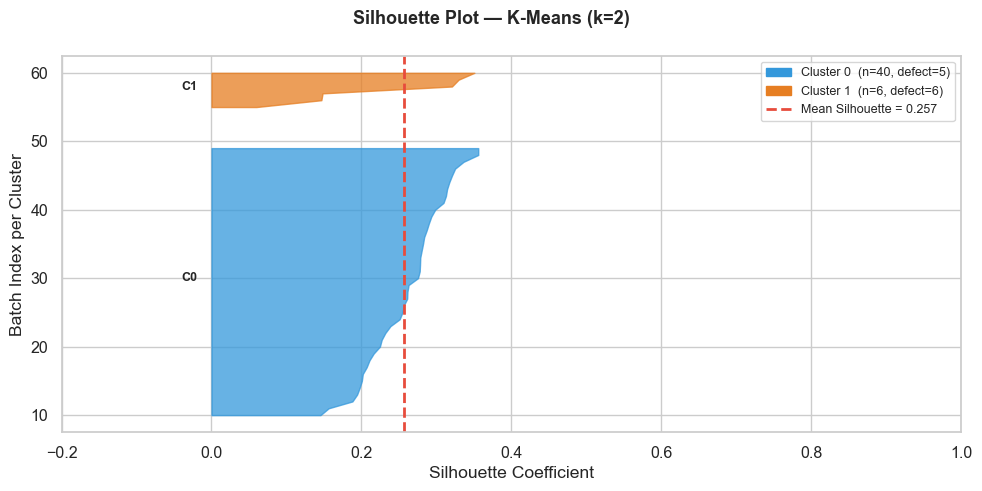

✅ Tersimpan: outputs/silhouette_plot.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(f'Silhouette Plot — K-Means (k={OPTIMAL_K})', fontsize=13, fontweight='bold')

sil_vals = silhouette_samples(X_scaled, cluster_labels)
y_lower  = 10
legend_patches = []

for i in range(OPTIMAL_K):
    sil_i = np.sort(sil_vals[cluster_labels == i])
    size_i = sil_i.shape[0]
    y_upper = y_lower + size_i
    color = CLUSTER_COLORS[i % len(CLUSTER_COLORS)]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i, color=color, alpha=0.75)
    ax.text(-0.04, y_lower + size_i/2, f'C{i}', fontsize=9, va='center', fontweight='bold')
    y_lower = y_upper + 5
    defect_n = int((y[cluster_labels==i]==1).sum())
    legend_patches.append(mpatches.Patch(color=color,
        label=f'Cluster {i}  (n={size_i}, defect={defect_n})'))

ax.axvline(sil_final, color='#e74c3c', linestyle='--', lw=2,
            label=f'Mean Silhouette = {sil_final:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Batch Index per Cluster')
ax.set_xlim([-0.2, 1.0])
ax.legend(handles=legend_patches + [ax.get_lines()[0]], loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Tersimpan: outputs/silhouette_plot.png')


## 🔭 7. Visualisasi PCA

PCA (Principal Component Analysis) mereduksi dimensi fitur ke 2D dan 3D  
agar pola cluster dapat divisualisasikan secara intuitif.


In [ ]:
# PCA 2D
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
var2 = pca2.explained_variance_ratio_

# PCA 3D
pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)
var3 = pca3.explained_variance_ratio_

print(f'PCA 2D — Variance explained: PC1={var2[0]*100:.1f}%, PC2={var2[1]*100:.1f}%  Total={sum(var2)*100:.1f}%')
print(f'PCA 3D — Variance explained: PC1={var3[0]*100:.1f}%, PC2={var3[1]*100:.1f}%, PC3={var3[2]*100:.1f}%  Total={sum(var3)*100:.1f}%')


PCA 2D — Variance explained: PC1=16.9%, PC2=14.3%  Total=31.2%
PCA 3D — Variance explained: PC1=16.9%, PC2=14.3%, PC3=7.4%  Total=38.6%


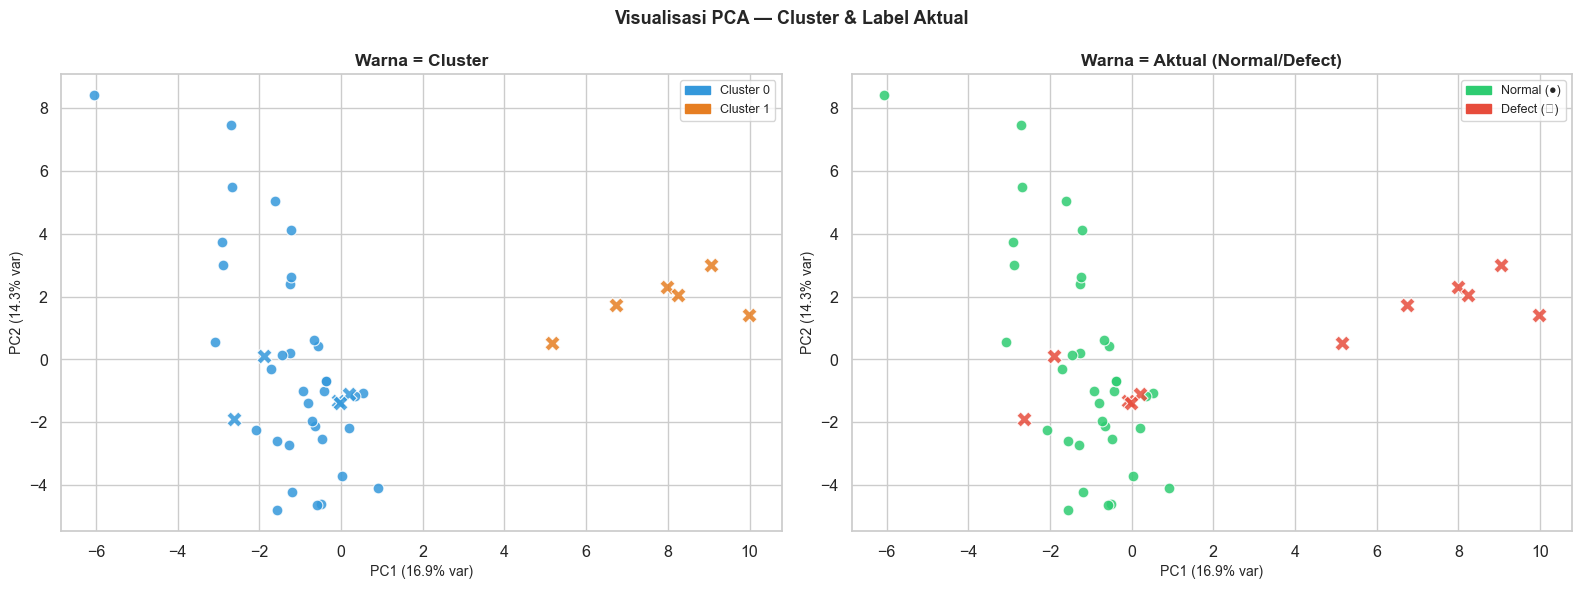

✅ Tersimpan: outputs/pca_2d_clusters.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Visualisasi PCA — Cluster & Label Aktual', fontsize=13, fontweight='bold')

markers_defect = {0: 'o', 1: 'X'}
ms_defect      = {0: 60,  1: 120}

for ax_idx, (ax, title) in enumerate(zip(axes, ['Warna = Cluster', 'Warna = Aktual (Normal/Defect)'])):
    for i in range(len(X_pca2)):
        lbl    = cluster_labels[i]
        is_def = int(y.iloc[i])
        color  = CLUSTER_COLORS[lbl % len(CLUSTER_COLORS)] if ax_idx==0 else PALETTE[is_def]
        marker = markers_defect[is_def]
        ms     = ms_defect[is_def]
        ax.scatter(X_pca2[i, 0], X_pca2[i, 1], c=color, marker=marker,
                   s=ms, edgecolors='white', linewidth=0.8, alpha=0.85)

    ax.set_xlabel(f'PC1 ({var2[0]*100:.1f}% var)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var2[1]*100:.1f}% var)', fontsize=10)
    ax.set_title(title, fontweight='bold')

    if ax_idx == 0:
        patches = [mpatches.Patch(color=CLUSTER_COLORS[i%len(CLUSTER_COLORS)],
                    label=f'Cluster {i}') for i in range(OPTIMAL_K)]
    else:
        patches = [mpatches.Patch(color=PALETTE[0], label='Normal (●)'),
                   mpatches.Patch(color=PALETTE[1], label='Defect (✕)')]
    ax.legend(handles=patches, fontsize=9, loc='best')

plt.tight_layout()
plt.savefig('outputs/pca_2d_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Tersimpan: outputs/pca_2d_clusters.png')


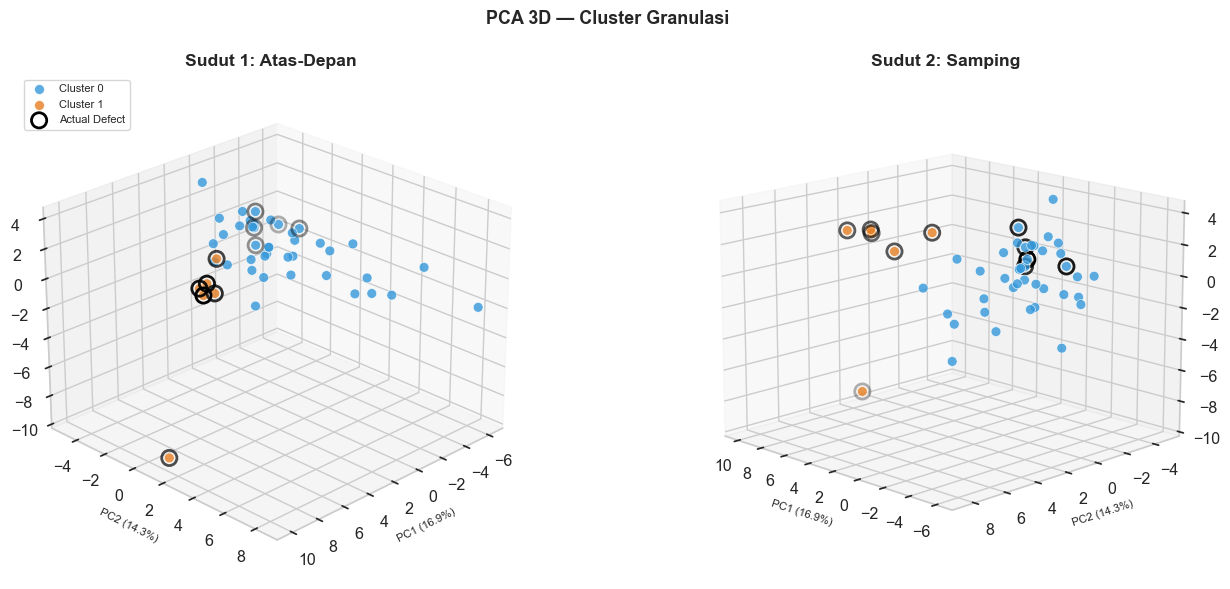

✅ Tersimpan: outputs/pca_3d_clusters.png


In [ ]:
# PCA 3D
fig = plt.figure(figsize=(14, 6))
fig.suptitle('PCA 3D — Cluster Granulasi', fontsize=13, fontweight='bold')

for ax_idx, (elev, azim, title) in enumerate([
    (25, 45,  'Sudut 1: Atas-Depan'),
    (15, 135, 'Sudut 2: Samping')
]):
    ax = fig.add_subplot(1, 2, ax_idx+1, projection='3d')
    for ci in range(OPTIMAL_K):
        mask = cluster_labels == ci
        color = CLUSTER_COLORS[ci % len(CLUSTER_COLORS)]
        ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
                   c=color, s=50, alpha=0.80, edgecolors='white', linewidth=0.5,
                   label=f'Cluster {ci}')
    # Tandai defect
    def_mask = y.values == 1
    ax.scatter(X_pca3[def_mask, 0], X_pca3[def_mask, 1], X_pca3[def_mask, 2],
               c='none', edgecolors='black', s=120, linewidth=2,
               marker='o', label='Actual Defect', zorder=5)

    ax.set_xlabel(f'PC1 ({var3[0]*100:.1f}%)', fontsize=8)
    ax.set_ylabel(f'PC2 ({var3[1]*100:.1f}%)', fontsize=8)
    ax.set_zlabel(f'PC3 ({var3[2]*100:.1f}%)', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.view_init(elev=elev, azim=azim)
    if ax_idx == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/pca_3d_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Tersimpan: outputs/pca_3d_clusters.png')


## 📋 8. Profil Setiap Cluster

Karakterisasi setiap cluster berdasarkan rata-rata parameter kritis proses.  
Perbandingan Z-score dipakai agar skala antar fitur setara.


In [ ]:
# Fitur kunci untuk profiling
PROFILE_FEATURES = {
    'Suhu CB1 Rata'    : 'cb1_suhu_rata',
    'Suhu CB1 Std'     : 'cb1_suhu_std',
    'Suhu CB2 Rata'    : 'cb2_suhu_rata',
    'Suhu CB2 Std'     : 'cb2_suhu_std',
    'Waktu CB1 L1P1'   : 'cb1_waktu_lot1_ph1',
    'Waktu CB1 L2P1'   : 'cb1_waktu_lot2_ph1',
    'Waktu CB2 L1'     : 'cb2_waktu_lot1_ph1',
    'Waktu CB2 L2'     : 'cb2_waktu_lot2_ph1',
    'KA CB1'           : 'cb1_rata_ka',
    'KA CB2'           : 'cb2_rata_ka',
    'KA CK1'           : 'ck1_ka_setelah_ck',
    'Yield CB1 (%)'    : 'cb1_pct_yield',
    'Yield CB1 Dev'    : 'cb1_yield_deviate',
    'Yield CK1 (%)'    : 'ck1_pct_yield',
    'Yield CB2 (%)'    : 'cb2_pct_yield',
    'Granul CB1 (kg)'  : 'cb1_jml_granul_kg',
    'Granul CB2 (kg)'  : 'cb2_jml_granul_kg',
}
PROFILE_FEATURES = {k: v for k, v in PROFILE_FEATURES.items() if v in df.columns}

# Hitung mean per cluster & defect rate
profile_rows = {}
for ci in range(OPTIMAL_K):
    mask = df['Cluster'] == ci
    row  = {'n': int(mask.sum()),
            'Defect (%)': round(float(df.loc[mask, TARGET].mean()*100), 1)}
    for label, col in PROFILE_FEATURES.items():
        row[label] = round(float(df.loc[mask, col].mean()), 3)
    profile_rows[f'Cluster {ci}'] = row

profile_df = pd.DataFrame(profile_rows).T
print('=== Profil Cluster ===')
print(profile_df.to_string())


=== Profil Cluster ===
              n  Defect (%)  Suhu CB1 Rata  Suhu CB1 Std  Suhu CB2 Rata  Suhu CB2 Std  Waktu CB1 L1P1  Waktu CB1 L2P1  Waktu CB2 L1  Waktu CB2 L2  KA CB1  KA CB2  KA CK1  Yield CB1 (%)  Yield CB1 Dev  Yield CK1 (%)  Yield CB2 (%)  Granul CB1 (kg)  Granul CB2 (kg)
Cluster 0  40.0        12.5         73.903         0.408         71.648         0.303          16.722          16.314        33.307        33.469   4.974   3.359   4.695        100.745          0.075         99.335        101.018          301.229          536.962
Cluster 1   6.0       100.0         77.973         2.005         71.610         0.064          31.753           0.000        27.708        28.035   4.990   3.358   4.853        100.686          0.667        100.418         84.344          301.050          538.250


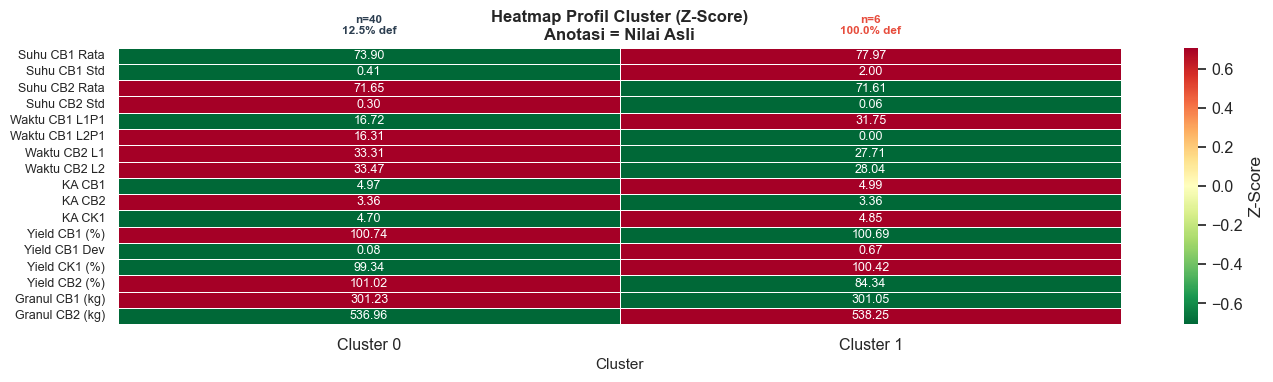

✅ Tersimpan: outputs/cluster_profile_heatmap.png


In [ ]:
# Heatmap Z-score profil cluster
feat_cols = list(PROFILE_FEATURES.keys())
heatmap_data = profile_df[feat_cols].astype(float)

# Z-score normalisasi per fitur (kolom)
heatmap_z = (heatmap_data - heatmap_data.mean()) / (heatmap_data.std() + 1e-9)

fig, ax = plt.subplots(figsize=(14, max(4, OPTIMAL_K*1.2)))
sns.heatmap(
    heatmap_z.T,
    annot     = heatmap_data.T.round(2),
    fmt       = '.2f',
    cmap      = 'RdYlGn_r',
    linewidths= 0.4,
    linecolor = 'white',
    ax        = ax,
    annot_kws = {'size': 9},
    cbar_kws  = {'label': 'Z-Score'}
)
ax.set_title('Heatmap Profil Cluster (Z-Score)\nAnotasi = Nilai Asli',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Cluster', fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

# Tambahkan info defect rate & n di header
for ci in range(OPTIMAL_K):
    dr = profile_df.iloc[ci]['Defect (%)']
    n  = profile_df.iloc[ci]['n']
    ax.text(ci + 0.5, -0.7, f'n={int(n)}\n{dr}% def',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color='#e74c3c' if dr > 30 else '#2c3e50')

plt.tight_layout()
plt.savefig('outputs/cluster_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Tersimpan: outputs/cluster_profile_heatmap.png')


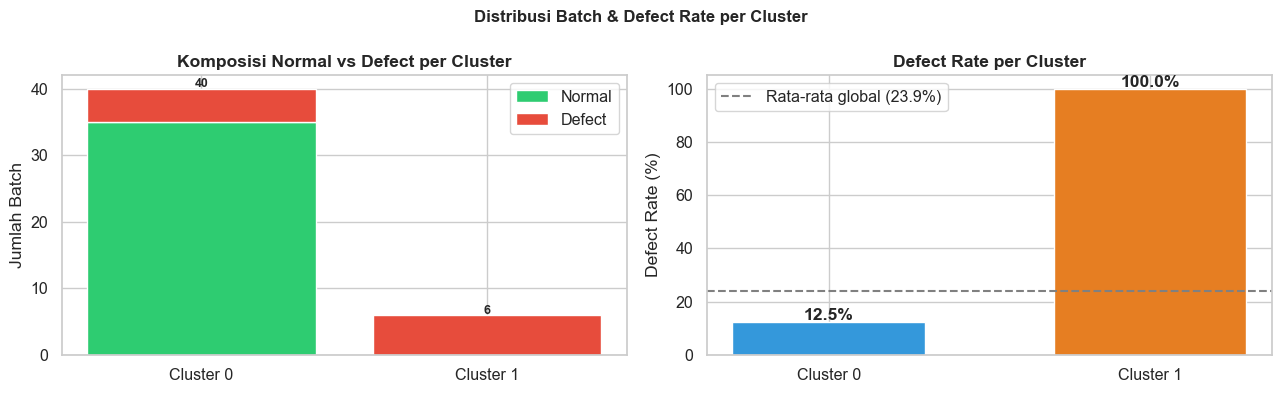

✅ Tersimpan: outputs/cluster_defect_distribution.png


In [ ]:
# Bar chart defect rate per cluster
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Batch & Defect Rate per Cluster', fontsize=12, fontweight='bold')

cluster_names = [f'Cluster {i}' for i in range(OPTIMAL_K)]
defect_rates  = [float(profile_df.loc[f'Cluster {i}', 'Defect (%)']) for i in range(OPTIMAL_K)]
totals        = [int(profile_df.loc[f'Cluster {i}', 'n']) for i in range(OPTIMAL_K)]
normals       = [int((df[df.Cluster==i][TARGET]==0).sum()) for i in range(OPTIMAL_K)]
defects       = [int((df[df.Cluster==i][TARGET]==1).sum()) for i in range(OPTIMAL_K)]
bar_colors    = [CLUSTER_COLORS[i%len(CLUSTER_COLORS)] for i in range(OPTIMAL_K)]

# Stacked bar: Normal vs Defect
bars_n = axes[0].bar(cluster_names, normals, color='#2ecc71', label='Normal', edgecolor='white')
bars_d = axes[0].bar(cluster_names, defects, bottom=normals, color='#e74c3c',
                      label='Defect', edgecolor='white')
for i, (n, d) in enumerate(zip(normals, defects)):
    axes[0].text(i, n+d+0.2, f'{n+d}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Jumlah Batch')
axes[0].set_title('Komposisi Normal vs Defect per Cluster', fontweight='bold')
axes[0].legend()

# Defect rate bars
bar_dr = axes[1].bar(cluster_names, defect_rates, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bar_dr, defect_rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].axhline(df[TARGET].mean()*100, color='gray', linestyle='--', lw=1.5,
                 label=f'Rata-rata global ({df[TARGET].mean()*100:.1f}%)')
axes[1].set_ylabel('Defect Rate (%)')
axes[1].set_title('Defect Rate per Cluster', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/cluster_defect_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Tersimpan: outputs/cluster_defect_distribution.png')


## 🔗 9. Analisis Korelasi Antar Fitur Kritis

Heatmap korelasi Pearson antar parameter proses kritis dengan `is_defect` dan dikelompokkan per proses (CB1, CB2


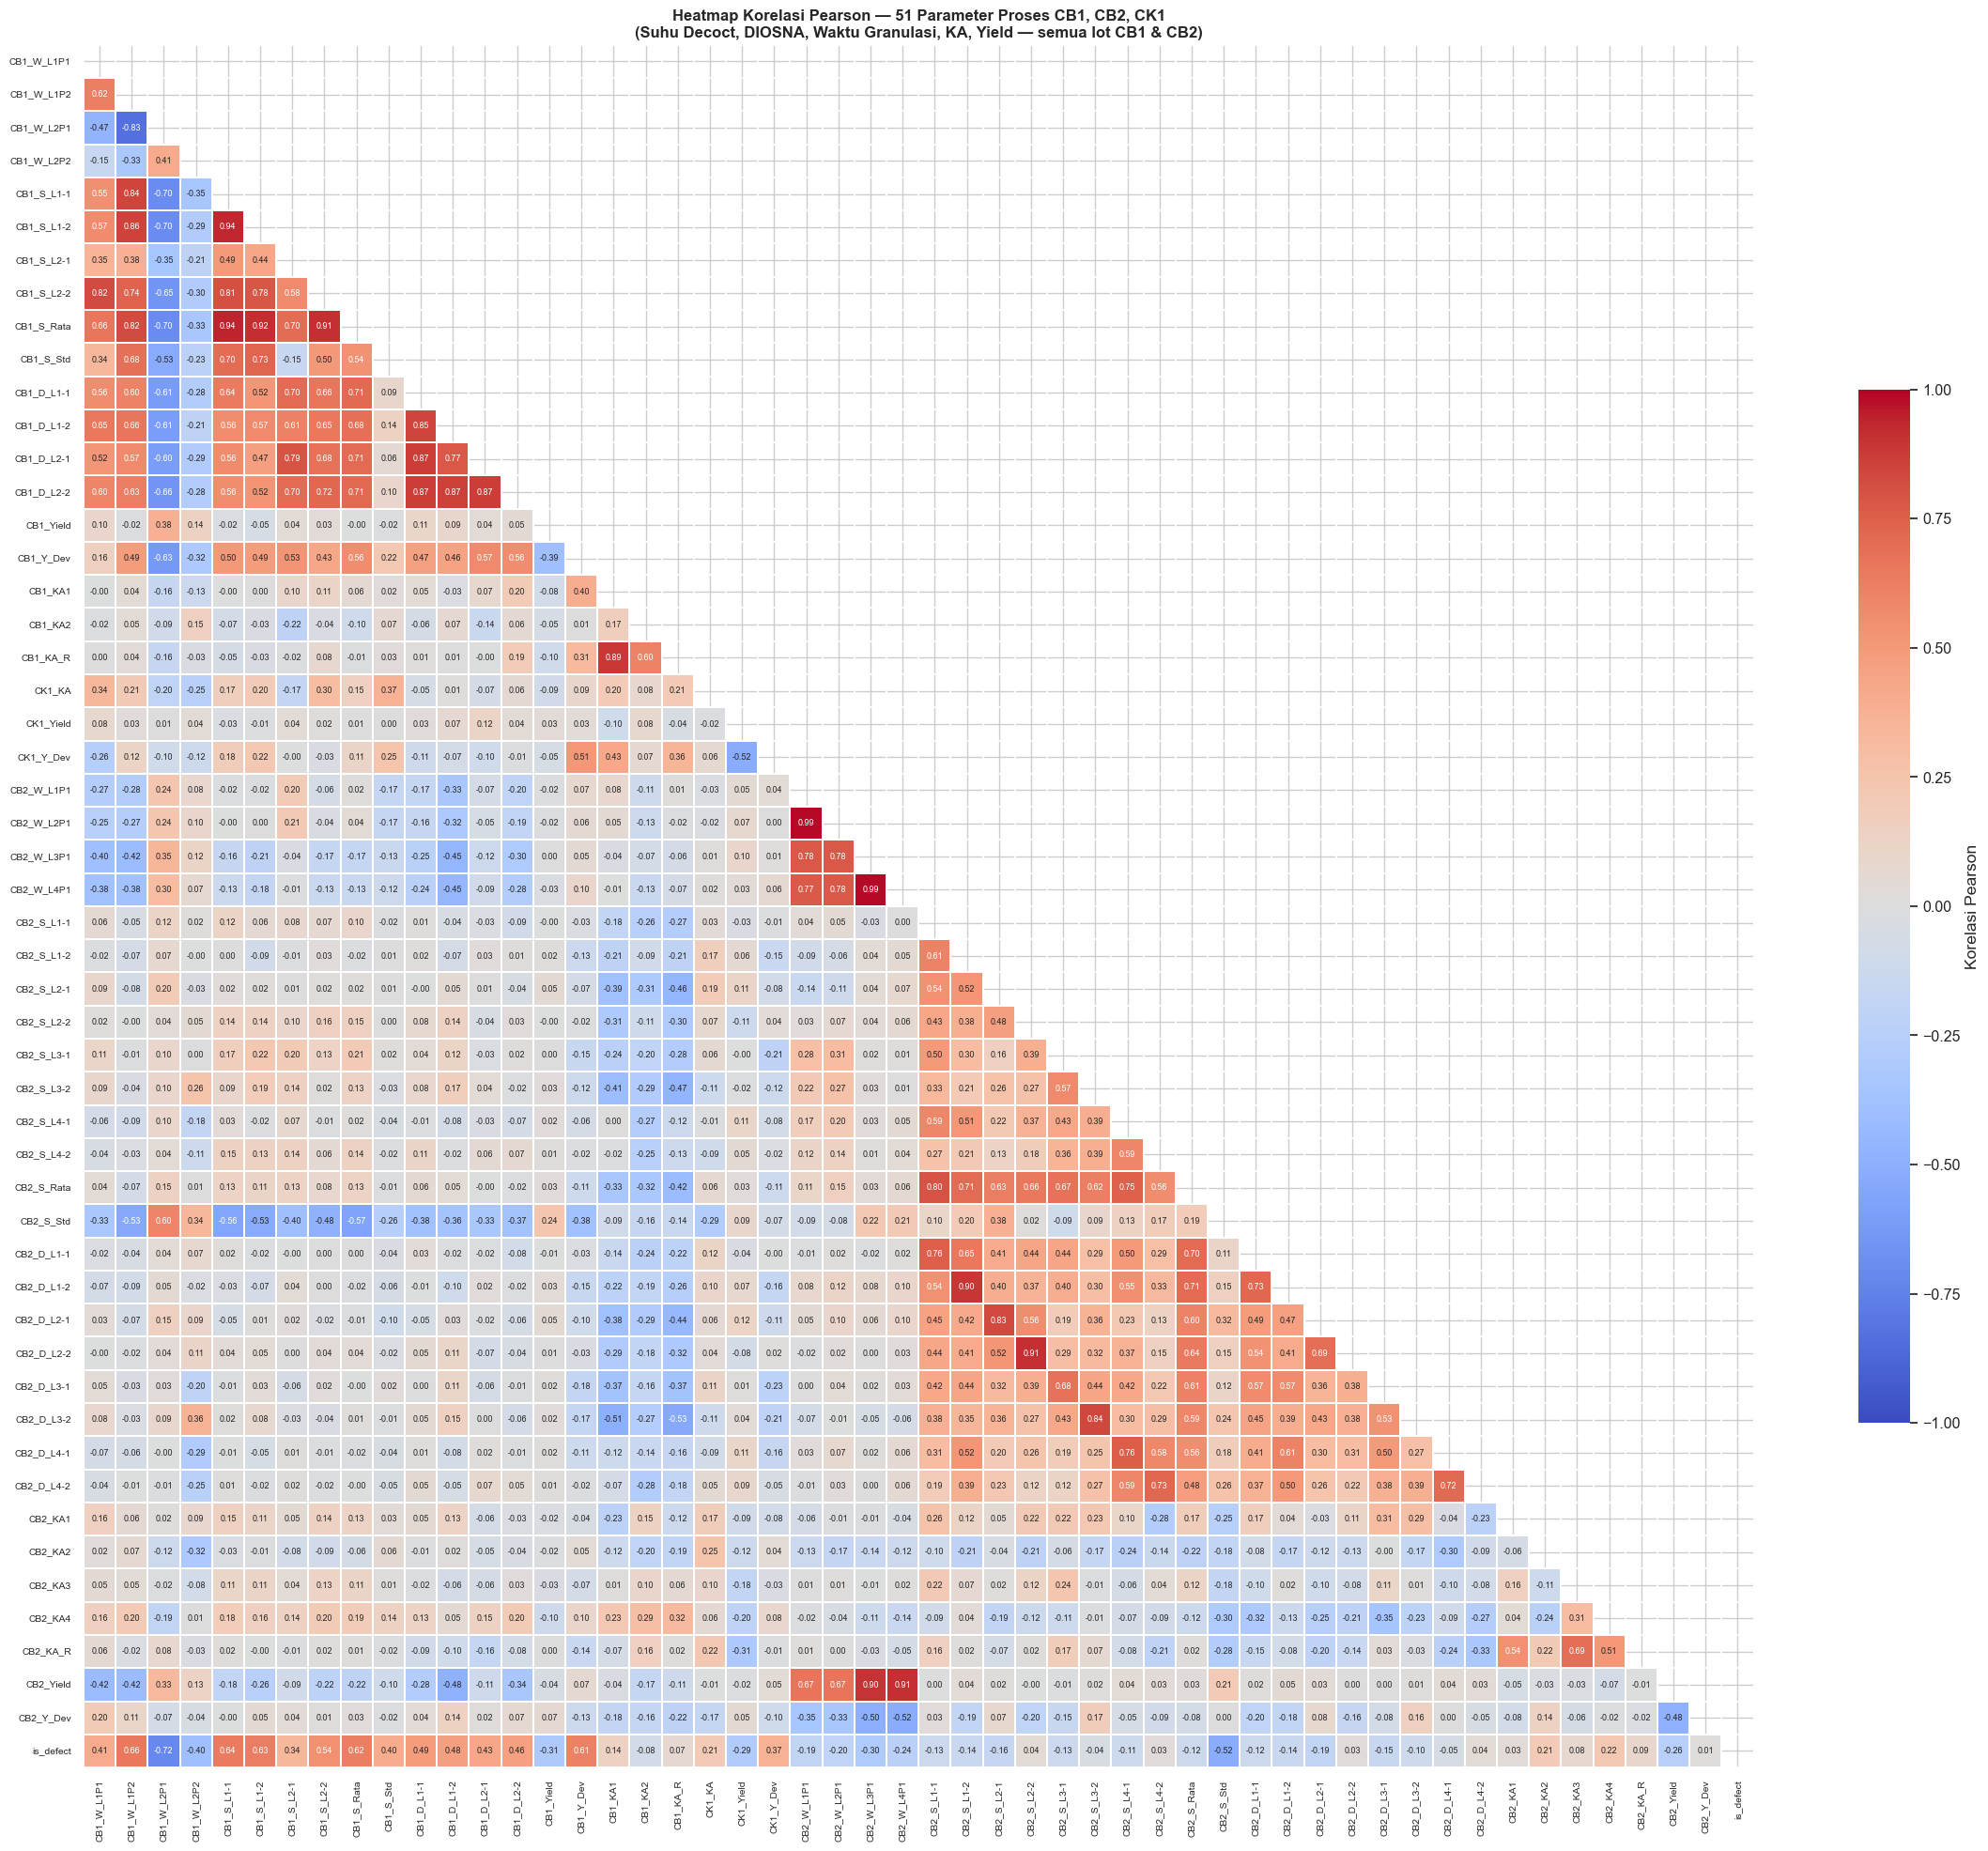


Total fitur dianalisis : 51

Top 20 fitur berkorelasi dengan is_defect:
  cb1_waktu_lot2_ph1                       r = -0.7185  ██████████████
  cb1_waktu_lot1_ph2                       r = +0.6552  █████████████
  cb1_suhu_lot1_1                          r = +0.6375  ████████████
  cb1_suhu_lot1_2                          r = +0.6267  ████████████
  cb1_suhu_rata                            r = +0.6226  ████████████
  cb1_yield_deviate                        r = +0.6138  ████████████
  cb1_suhu_lot2_2                          r = +0.5403  ██████████
  cb2_suhu_std                             r = -0.5208  ██████████
  cb1_suhu_diosna_lot1_1                   r = +0.4908  █████████
  cb1_suhu_diosna_lot1_2                   r = +0.4755  █████████
  cb1_suhu_diosna_lot2_2                   r = +0.4635  █████████
  cb1_suhu_diosna_lot2_1                   r = +0.4325  ████████
  cb1_waktu_lot1_ph1                       r = +0.4105  ████████
  cb1_suhu_std                             r = +

In [ ]:
# Fitur untuk heatmap korelasi
CORR_FEATURES = [
    # Waktu Granulasi CB1
    'cb1_waktu_lot1_ph1', 'cb1_waktu_lot1_ph2',
    'cb1_waktu_lot2_ph1', 'cb1_waktu_lot2_ph2',

    # Suhu Decoct CB1
    'cb1_suhu_lot1_1', 'cb1_suhu_lot1_2',
    'cb1_suhu_lot2_1', 'cb1_suhu_lot2_2',
    'cb1_suhu_rata',   'cb1_suhu_std',

    # Suhu DIOSNA CB1
    'cb1_suhu_diosna_lot1_1', 'cb1_suhu_diosna_lot1_2',
    'cb1_suhu_diosna_lot2_1', 'cb1_suhu_diosna_lot2_2',

    # KA & Yield CB1 & CK1
    'cb1_pct_yield',    'cb1_yield_deviate',
    'cb1_ka1',          'cb1_ka2',
    'cb1_rata_ka',      'ck1_ka_setelah_ck',
    'ck1_pct_yield',    'ck1_yield_deviate',

    # Waktu Granulasi CB2
    'cb2_waktu_lot1_ph1', 'cb2_waktu_lot2_ph1',
    'cb2_waktu_lot3_ph1', 'cb2_waktu_lot4_ph1',

    # Suhu Decoct CB2
    'cb2_suhu_lot1_1', 'cb2_suhu_lot1_2',
    'cb2_suhu_lot2_1', 'cb2_suhu_lot2_2',
    'cb2_suhu_lot3_1', 'cb2_suhu_lot3_2',
    'cb2_suhu_lot4_1', 'cb2_suhu_lot4_2',
    'cb2_suhu_rata',   'cb2_suhu_std',

    # Suhu DIOSNA CB2
    'cb2_suhu_diosna_lot1_1', 'cb2_suhu_diosna_lot1_2',
    'cb2_suhu_diosna_lot2_1', 'cb2_suhu_diosna_lot2_2',
    'cb2_suhu_diosna_lot3_1', 'cb2_suhu_diosna_lot3_2',
    'cb2_suhu_diosna_lot4_1', 'cb2_suhu_diosna_lot4_2',

    # KA & Yield CB2
    'cb2_ka1',      'cb2_ka2',
    'cb2_ka3',      'cb2_ka4',
    'cb2_rata_ka',  'cb2_pct_yield', 'cb2_yield_deviate',

    TARGET,
]
CORR_FEATURES = [c for c in CORR_FEATURES if c in df.columns]

corr_matrix = df[CORR_FEATURES].corr()

# Rename ringkas untuk tampilan heatmap
rename_map = {
    'cb1_waktu_lot1_ph1': 'CB1_W_L1P1', 'cb1_waktu_lot1_ph2': 'CB1_W_L1P2',
    'cb1_waktu_lot2_ph1': 'CB1_W_L2P1', 'cb1_waktu_lot2_ph2': 'CB1_W_L2P2',
    'cb1_suhu_lot1_1'   : 'CB1_S_L1-1', 'cb1_suhu_lot1_2'   : 'CB1_S_L1-2',
    'cb1_suhu_lot2_1'   : 'CB1_S_L2-1', 'cb1_suhu_lot2_2'   : 'CB1_S_L2-2',
    'cb1_suhu_rata'     : 'CB1_S_Rata', 'cb1_suhu_std'       : 'CB1_S_Std',
    'cb1_suhu_diosna_lot1_1': 'CB1_D_L1-1', 'cb1_suhu_diosna_lot1_2': 'CB1_D_L1-2',
    'cb1_suhu_diosna_lot2_1': 'CB1_D_L2-1', 'cb1_suhu_diosna_lot2_2': 'CB1_D_L2-2',
    'cb1_pct_yield'     : 'CB1_Yield',  'cb1_yield_deviate'  : 'CB1_Y_Dev',
    'cb1_ka1'           : 'CB1_KA1',    'cb1_ka2'            : 'CB1_KA2',
    'cb1_rata_ka'       : 'CB1_KA_R',   'ck1_ka_setelah_ck'  : 'CK1_KA',
    'ck1_pct_yield'     : 'CK1_Yield',  'ck1_yield_deviate'  : 'CK1_Y_Dev',
    'cb2_waktu_lot1_ph1': 'CB2_W_L1P1', 'cb2_waktu_lot2_ph1': 'CB2_W_L2P1',
    'cb2_waktu_lot3_ph1': 'CB2_W_L3P1', 'cb2_waktu_lot4_ph1': 'CB2_W_L4P1',
    'cb2_suhu_lot1_1'   : 'CB2_S_L1-1', 'cb2_suhu_lot1_2'   : 'CB2_S_L1-2',
    'cb2_suhu_lot2_1'   : 'CB2_S_L2-1', 'cb2_suhu_lot2_2'   : 'CB2_S_L2-2',
    'cb2_suhu_lot3_1'   : 'CB2_S_L3-1', 'cb2_suhu_lot3_2'   : 'CB2_S_L3-2',
    'cb2_suhu_lot4_1'   : 'CB2_S_L4-1', 'cb2_suhu_lot4_2'   : 'CB2_S_L4-2',
    'cb2_suhu_rata'     : 'CB2_S_Rata', 'cb2_suhu_std'       : 'CB2_S_Std',
    'cb2_suhu_diosna_lot1_1': 'CB2_D_L1-1', 'cb2_suhu_diosna_lot1_2': 'CB2_D_L1-2',
    'cb2_suhu_diosna_lot2_1': 'CB2_D_L2-1', 'cb2_suhu_diosna_lot2_2': 'CB2_D_L2-2',
    'cb2_suhu_diosna_lot3_1': 'CB2_D_L3-1', 'cb2_suhu_diosna_lot3_2': 'CB2_D_L3-2',
    'cb2_suhu_diosna_lot4_1': 'CB2_D_L4-1', 'cb2_suhu_diosna_lot4_2': 'CB2_D_L4-2',
    'cb2_ka1'           : 'CB2_KA1',    'cb2_ka2'            : 'CB2_KA2',
    'cb2_ka3'           : 'CB2_KA3',    'cb2_ka4'            : 'CB2_KA4',
    'cb2_rata_ka'       : 'CB2_KA_R',   'cb2_pct_yield'      : 'CB2_Yield',
    'cb2_yield_deviate' : 'CB2_Y_Dev',
    TARGET              : 'is_defect',
}
corr_renamed = corr_matrix.rename(index=rename_map, columns=rename_map)

# Heatmap
n_feats = len(CORR_FEATURES)
fig_size = max(18, n_feats * 0.45)
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))
mask = np.triu(np.ones_like(corr_renamed, dtype=bool))
sns.heatmap(
    corr_renamed, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, linewidths=0.25, linecolor='white',
    annot_kws={'size': 6.5}, ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Korelasi Pearson'}
)
ax.set_title(
    f'Heatmap Korelasi Pearson — {n_feats-1} Parameter Proses CB1, CB2, CK1\n'
    '(Suhu Decoct, DIOSNA, Waktu Granulasi, KA, Yield — semua lot CB1 & CB2)',
    fontweight='bold', fontsize=12
)
ax.tick_params(axis='x', rotation=90, labelsize=7.5)
ax.tick_params(axis='y', rotation=0,  labelsize=7.5)
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top korelasi dengan is_defect
corr_with_target = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print(f'\nTotal fitur dianalisis : {n_feats - 1}')
print('\nTop 20 fitur berkorelasi dengan is_defect:')
for col, val in corr_with_target.head(20).items():
    r_val = corr_matrix[TARGET][col]
    bar   = '█' * int(abs(r_val) * 20)
    print(f'  {col:<40} r = {r_val:+.4f}  {bar}')
print('\n✅ Tersimpan: outputs/correlation_heatmap.png')


## 📌 10. Fitur Paling Berpengaruh terhadap Keanggotaan Cluster

Random Forest dilatih untuk memprediksi cluster label (multi-class),  
kemudian Gini Importance dipakai untuk mengidentifikasi fitur mana yang  
paling membedakan satu cluster dari yang lain.


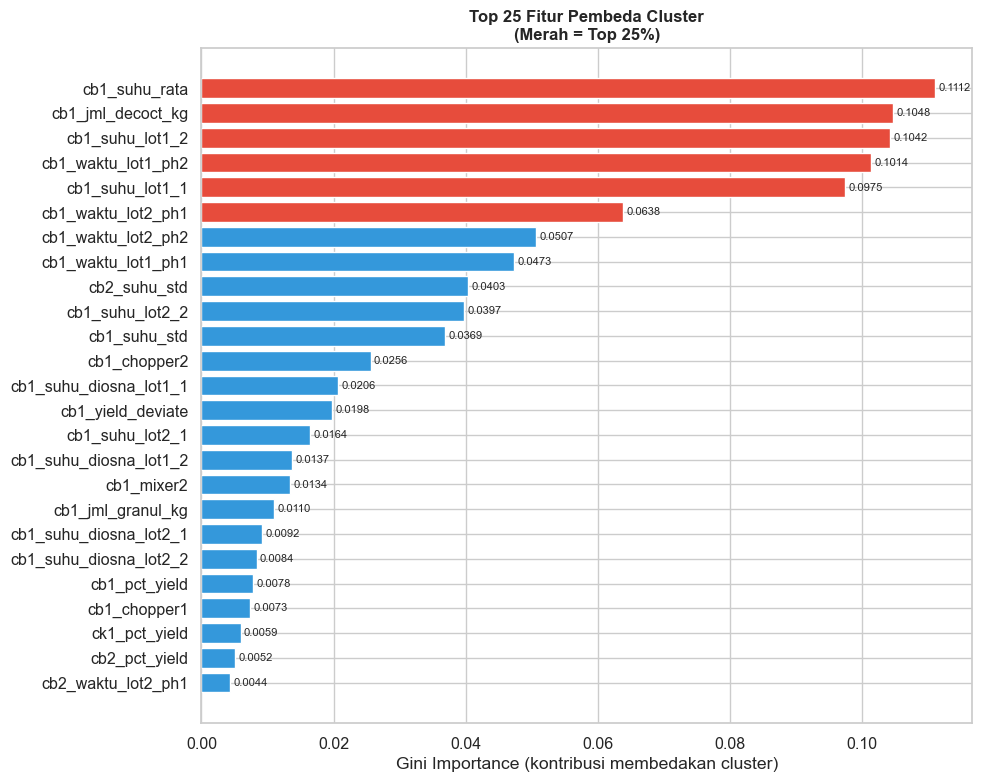


🏆 Top 15 Fitur Pembeda Cluster:
cb1_suhu_rata             0.1112
cb1_jml_decoct_kg         0.1048
cb1_suhu_lot1_2           0.1042
cb1_waktu_lot1_ph2        0.1014
cb1_suhu_lot1_1           0.0975
cb1_waktu_lot2_ph1        0.0638
cb1_waktu_lot2_ph2        0.0507
cb1_waktu_lot1_ph1        0.0473
cb2_suhu_std              0.0403
cb1_suhu_lot2_2           0.0397
cb1_suhu_std              0.0369
cb1_chopper2              0.0256
cb1_suhu_diosna_lot1_1    0.0206
cb1_yield_deviate         0.0198
cb1_suhu_lot2_1           0.0164

✅ Tersimpan: outputs/cluster_feature_importance.png


In [ ]:
# RF untuk feature importance cluster
rf_clust = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = 10,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)
rf_clust.fit(X_scaled, cluster_labels)

imp_series = pd.Series(rf_clust.feature_importances_, index=CLUSTER_FEATURES)
imp_series = imp_series.sort_values(ascending=False)

TOP_N = min(25, len(imp_series))
top_imp = imp_series.head(TOP_N).sort_values()
bar_colors_imp = ['#e74c3c' if v > top_imp.quantile(0.75) else '#3498db'
                  for v in top_imp.values]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_imp.index, top_imp.values, color=bar_colors_imp, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 0.0005, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=8)
ax.set_xlabel('Gini Importance (kontribusi membedakan cluster)')
ax.set_title(f'Top {TOP_N} Fitur Pembeda Cluster\n(Merah = Top 25%)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/cluster_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Top 15 Fitur Pembeda Cluster:')
print(imp_series.head(15).round(4).to_string())
print('\n✅ Tersimpan: outputs/cluster_feature_importance.png')


## 📡 11. Radar Chart — Perbandingan Profil Cluster

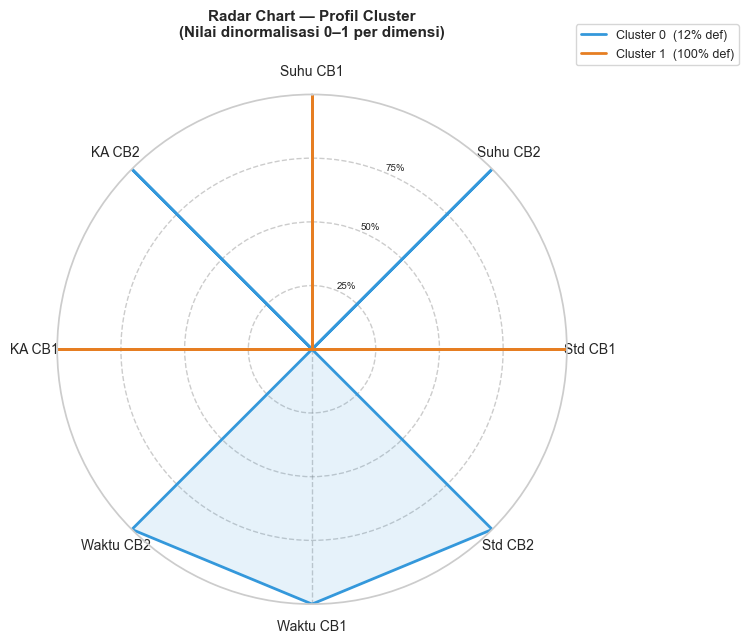

✅ Tersimpan: outputs/cluster_radar_chart.png


In [ ]:
# Radar chart: 8 dimensi kunci per cluster
RADAR_FEATURES = {
    'Suhu CB1':  'cb1_suhu_rata',
    'Suhu CB2':  'cb2_suhu_rata',
    'Std CB1':   'cb1_suhu_std',
    'Std CB2':   'cb2_suhu_std',
    'Waktu CB1': 'cb1_waktu_lot2_ph1',
    'Waktu CB2': 'cb2_waktu_lot1_ph1',
    'KA CB1':    'cb1_rata_ka',
    'KA CB2':    'cb2_rata_ka',
}
RADAR_FEATURES = {k: v for k, v in RADAR_FEATURES.items() if v in df.columns}

radar_labels = list(RADAR_FEATURES.keys())
N = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Normalisasi 0-1 per fitur
radar_df = pd.DataFrame({k: df.groupby('Cluster')[v].mean()
                         for k, v in RADAR_FEATURES.items()})
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%','50%','75%'], fontsize=7)
ax.grid(color='gray', linestyle='--', alpha=0.4)

for ci in range(OPTIMAL_K):
    vals = radar_norm.iloc[ci].tolist() + [radar_norm.iloc[ci].tolist()[0]]
    dr   = defect_rates[ci]
    color = CLUSTER_COLORS[ci % len(CLUSTER_COLORS)]
    ax.plot(angles, vals, lw=2, color=color, label=f'Cluster {ci}  ({dr:.0f}% def)')
    ax.fill(angles, vals, color=color, alpha=0.12)

ax.set_title('Radar Chart — Profil Cluster\n(Nilai dinormalisasi 0–1 per dimensi)',
             fontweight='bold', fontsize=11, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('outputs/cluster_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Tersimpan: outputs/cluster_radar_chart.png')


## 💡 12. Interpretasi & Penamaan Cluster

In [ ]:
print('='*65)
print('  INTERPRETASI CLUSTER — PJK-GM016')
print('='*65)
print(f'  K-Means k={OPTIMAL_K}, Silhouette={sil_final:.4f}, DB={db_final:.4f}')
print()

for ci in range(OPTIMAL_K):
    n     = int(profile_df.loc[f'Cluster {ci}', 'n'])
    dr    = float(profile_df.loc[f'Cluster {ci}', 'Defect (%)'])
    risk  = '🔴 HIGH RISK' if dr > 50 else ('🟡 MEDIUM RISK' if dr > 15 else '🟢 LOW RISK')

    # Karakteristik suhu
    s_cb1 = profile_df.loc[f'Cluster {ci}', 'Suhu CB1 Rata'] if 'Suhu CB1 Rata' in profile_df.columns else float('nan')
    s_cb2 = profile_df.loc[f'Cluster {ci}', 'Suhu CB2 Rata'] if 'Suhu CB2 Rata' in profile_df.columns else float('nan')
    ka    = profile_df.loc[f'Cluster {ci}', 'KA CB1'] if 'KA CB1' in profile_df.columns else float('nan')
    yld   = profile_df.loc[f'Cluster {ci}', 'Yield CB1 (%)'] if 'Yield CB1 (%)' in profile_df.columns else float('nan')

    print(f'  Cluster {ci}  {risk}')
    print(f'    ├─ Jumlah batch  : {n}')
    print(f'    ├─ Defect rate   : {dr:.1f}%')
    print(f'    ├─ Suhu CB1 rata : {s_cb1:.2f}°C')
    print(f'    ├─ Suhu CB2 rata : {s_cb2:.2f}°C')
    print(f'    ├─ KA CB1 rata   : {ka:.3f}%')
    print(f'    └─ Yield CB1     : {yld:.2f}%')
    print()

print('Insight Utama:')
max_dr_c = int(pd.Series(defect_rates).idxmax())
min_dr_c = int(pd.Series(defect_rates).idxmin())
print(f'  → Cluster {max_dr_c} paling berisiko ({defect_rates[max_dr_c]:.0f}% defect)')
print(f'  → Cluster {min_dr_c} paling aman    ({defect_rates[min_dr_c]:.0f}% defect)')
print('  → Simpan laporan cluster untuk operator sebagai acuan kontrol proses.')


  INTERPRETASI CLUSTER — PJK-GM016
  K-Means k=2, Silhouette=0.2569, DB=1.5086

  Cluster 0  🟢 LOW RISK
    ├─ Jumlah batch  : 40
    ├─ Defect rate   : 12.5%
    ├─ Suhu CB1 rata : 73.90°C
    ├─ Suhu CB2 rata : 71.65°C
    ├─ KA CB1 rata   : 4.974%
    └─ Yield CB1     : 100.75%

  Cluster 1  🔴 HIGH RISK
    ├─ Jumlah batch  : 6
    ├─ Defect rate   : 100.0%
    ├─ Suhu CB1 rata : 77.97°C
    ├─ Suhu CB2 rata : 71.61°C
    ├─ KA CB1 rata   : 4.990%
    └─ Yield CB1     : 100.69%

Insight Utama:
  → Cluster 1 paling berisiko (100% defect)
  → Cluster 0 paling aman    (12% defect)
  → Simpan laporan cluster untuk operator sebagai acuan kontrol proses.


## 💾 13. Export Dataset Clustered & Simpan Model

In [ ]:
# Simpan dataset dengan cluster label
output_path = 'outputs/dataset_clustered.csv'
df.to_csv(output_path, index=False)
print(f'✅ Dataset clustered tersimpan: {output_path}')
print(f'   Shape: {df.shape}')
print(f'   Kolom baru: Cluster, Cluster_Label')

# Simpan model
joblib.dump(kmeans,       'models/kmeans_model.pkl')
joblib.dump(scaler_clust, 'models/scaler_clustering.pkl')
joblib.dump(pca2,         'models/pca_2d_model.pkl')
joblib.dump(pca3,         'models/pca_3d_model.pkl')
joblib.dump(rf_clust,     'models/rf_cluster_importance.pkl')

# Simpan metadata cluster
cluster_meta = {
    'optimal_k'         : OPTIMAL_K,
    'silhouette_score'  : float(sil_final),
    'davies_bouldin'    : float(db_final),
    'inertia'           : float(kmeans.inertia_),
    'cluster_features'  : CLUSTER_FEATURES,
    'pca2_var_ratio'    : var2.tolist(),
    'pca3_var_ratio'    : var3.tolist(),
    'cluster_profile'   : profile_df.to_dict(),
}
with open('models/cluster_metadata.json', 'w') as f:
    json.dump(cluster_meta, f, indent=2)

# Simpan daftar fitur cluster
with open('models/cluster_features.txt', 'w') as f:
    f.write('\n'.join(CLUSTER_FEATURES))

print()
print('✅ Model & artefak tersimpan di models/:')
print('   models/kmeans_model.pkl          ← model utama K-Means')
print('   models/scaler_clustering.pkl     ← StandardScaler clustering')
print('   models/pca_2d_model.pkl          ← PCA 2 komponen')
print('   models/pca_3d_model.pkl          ← PCA 3 komponen')
print('   models/rf_cluster_importance.pkl ← RF untuk feature importance')
print('   models/cluster_metadata.json     ← metadata lengkap')
print('   models/cluster_features.txt      ← daftar fitur')
print()
print('✅ Output di outputs/:')
print('   outputs/dataset_clustered.csv')
print('   outputs/clustering_k_selection.png')
print('   outputs/silhouette_plot.png')
print('   outputs/pca_2d_clusters.png')
print('   outputs/pca_3d_clusters.png')
print('   outputs/cluster_profile_heatmap.png')
print('   outputs/cluster_defect_distribution.png')
print('   outputs/correlation_heatmap.png')
print('   outputs/cluster_feature_importance.png')
print('   outputs/cluster_radar_chart.png')


✅ Dataset clustered tersimpan: outputs/dataset_clustered.csv
   Shape: (46, 152)
   Kolom baru: Cluster, Cluster_Label

✅ Model & artefak tersimpan di models/:
   models/kmeans_model.pkl          ← model utama K-Means
   models/scaler_clustering.pkl     ← StandardScaler clustering
   models/pca_2d_model.pkl          ← PCA 2 komponen
   models/pca_3d_model.pkl          ← PCA 3 komponen
   models/rf_cluster_importance.pkl ← RF untuk feature importance
   models/cluster_metadata.json     ← metadata lengkap
   models/cluster_features.txt      ← daftar fitur

✅ Output di outputs/:
   outputs/dataset_clustered.csv
   outputs/clustering_k_selection.png
   outputs/silhouette_plot.png
   outputs/pca_2d_clusters.png
   outputs/pca_3d_clusters.png
   outputs/cluster_profile_heatmap.png
   outputs/cluster_defect_distribution.png
   outputs/correlation_heatmap.png
   outputs/cluster_feature_importance.png
   outputs/cluster_radar_chart.png


## 📋 14. Ringkasan Hasil Clustering

In [ ]:
print('='*65)
print('  RINGKASAN CLUSTERING — PJK-GM016')
print('='*65)
print(f'  Algoritma         : K-Means (k={OPTIMAL_K})')
print(f'  Fitur             : {len(CLUSTER_FEATURES)} parameter proses (CB1 + CB2)')
print(f'  Silhouette Score  : {sil_final:.4f}')
print(f'  Davies-Bouldin    : {db_final:.4f}')
print(f'  Variance PCA-2D   : {sum(var2)*100:.1f}%')
print(f'  Variance PCA-3D   : {sum(var3)*100:.1f}%')
print()
print('  Distribusi Cluster:')
for ci in range(OPTIMAL_K):
    n  = int(profile_df.loc[f'Cluster {ci}', 'n'])
    dr = float(profile_df.loc[f'Cluster {ci}', 'Defect (%)'])
    print(f'    Cluster {ci}: {n:2d} batch, {dr:5.1f}% defect')
print()
print(f'  Fitur paling membedakan cluster:')
for feat, val in imp_series.head(5).items():
    print(f'    {feat:<40} {val:.4f}')
print()
print('='*65)


  RINGKASAN CLUSTERING — PJK-GM016
  Algoritma         : K-Means (k=2)
  Fitur             : 66 parameter proses (CB1 + CB2)
  Silhouette Score  : 0.2569
  Davies-Bouldin    : 1.5086
  Variance PCA-2D   : 31.2%
  Variance PCA-3D   : 38.6%

  Distribusi Cluster:
    Cluster 0: 40 batch,  12.5% defect
    Cluster 1:  6 batch, 100.0% defect

  Fitur paling membedakan cluster:
    cb1_suhu_rata                            0.1112
    cb1_jml_decoct_kg                        0.1048
    cb1_suhu_lot1_2                          0.1042
    cb1_waktu_lot1_ph2                       0.1014
    cb1_suhu_lot1_1                          0.0975

  → Lanjutkan ke 05_dashboard.ipynb untuk visualisasi interaktif.
